In [3]:
library(dplyr)
library(data.table)
library(ggplot2)
library(gridExtra)
library(stringr)
library(ggpmisc)
#library(DescTools)
library(lmtest)
library(utils)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Loading required package: ggpp


Attaching package: ‘ggpp’


The following object is masked from ‘package:ggplot2’:

    annotate


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




In [4]:
#install.packages("DescTools")

## Read in the data

In [5]:
pgs <- read.table("../20221109_singularity_pgsccalc_test/results/score/aggregated_scores.txt.gz", header = T)
# score calculated in pgsc_calc from 
# /u/project/geschwind/shared/GenomicDatasets-processed/ACE-ANALYSIS/freeze0/SPARK/imputed/

pgs$subject_sp_id <- gsub(".*\\_", "", pgs$IID)
# subject family ID
pgs$family_sf_id <- gsub("\\_.*", "", pgs$IID)
# extract family ID

In [6]:
indv <- read.csv("individuals_registration-2021-12-01.csv")
# general indv info

In [7]:
part_scores <-read.table("partial_SPARK_scores.csv", sep = ",", header = T)
# can now read them from here - file copied from elsewhere
# partial scores that kancheng calculated merged with his other score (?)

colnames(part_scores)[2]  <- "IID"

colnames(part_scores)[3]  <- "old_score"

part_scores$sum <- part_scores$PGS1 + part_scores$PGS2
# calculate sum - should be the same as the original full Kangchen score

In [8]:
head(part_scores)

,X,IID,old_score,PGS1,PGS2,PROP1,PROP2,sum
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,SF0000033_SP0000033,-53.57859,13.834582,-0.7941499,0.9906237,0.009376268,13.040432
2,2,SF0000229_SP0000195,-47.12149,17.966278,1.5447610,0.9094512,0.090548847,19.511039
3,3,SF0000747_SP0000747,-49.67674,4.518401,12.1471478,0.5959156,0.404084371,16.665549
4,4,SF0000834_SP0000967,-53.38856,7.436398,5.7015109,0.7768729,0.223127087,13.137909
5,5,SF0000834_SP0001066,-58.13101,1.927318,6.3451211,0.8174358,0.182564199,8.272439
6,6,SF0000834_SP0001169,-53.16729,3.917391,9.1615168,0.6407064,0.359293582,13.078908


In [9]:
pca <- read.table("chr1-chr22_pca.eigenvec")
# updated PCA from Jamal


colnames(pca) <- c("ns", "subject_sp_id", "PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10", "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18", "PC19", "PC20")
# add colnames


In [10]:
jamal_score <- read.table("SPARK_Pheno_Score_Table_01032022.txt", sep = "\t", header = T)
# updated scores from jamal's pgsc_calc run

colnames(jamal_score)[2] <- "subject_sp_id"
# rename
colnames(jamal_score)[7] <- "SCORE"
#rename
ancestry_ids <- jamal_score[c("subject_sp_id", "ancestry")]
# get ancestry alone - calculated by regeneron with HapMap3 database

In [11]:
total_df_pgsc <- merge(pgs,indv,by="subject_sp_id")
# merge my score with individual background info

total_df_pgsc  <- merge(total_df_pgsc, pca, by = "subject_sp_id")
# add pca data

total_df_pgsc$ASD <- as.integer(total_df_pgsc$asd)
# format column 

total_df_pgsc$SEX <- NA
total_df_pgsc[total_df_pgsc$sex == "Male",]$SEX <- 1
total_df_pgsc[total_df_pgsc$sex == "Female",]$SEX <- 0
#format sex column 

total_df_pgsc <- merge(total_df_pgsc,ancestry_ids,by="subject_sp_id")
# add the ancestry (taken from Jamal)

In [12]:
############ make df with jamal's scores and mine

j_m <- inner_join(jamal_score[,c("subject_sp_id", "SCORE")], total_df_pgsc[,c("subject_sp_id", "PGS000327_hmPOS_GRCh38_SUM")])

########### Change name for function ease of use ****************** used SUM for score
colnames(total_df_pgsc)[5] <- "SCORE"
#change name of score to use to mach jamal's data

Joining with `by = join_by(subject_sp_id)`


In [13]:
total_df_j  <- merge(jamal_score, pca, by = "subject_sp_id")
# add pca to jamal's data

total_df_j$ASD <- as.integer(total_df_j$asd)
# format
#total_df_j$SEX <- NA
# format
total_df_j$SEX <- total_df_j$sex12

In [22]:
fs_score_spark <- read.table("SPARK_PHENO_SIBS.txt", sep = "\t", header = T)
# family structure file

Warning message in file(file, "rt"):
“cannot open file 'SPARK_PHENO_SIBS.txt': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection


In [15]:
unrelated_indv <- read.csv("/u/project/pasaniuc/afcarrol/Projects/20230413_gcta_spark/unrelated_grm_text/unrelated_pop.csv")

## ancestry specific PRS

In [17]:
# create z score

anc_spec <- read.table("test.pgs.tsv", sep = "\t", header = T)

mean1 <- mean(anc_spec$PGS1)
sd1 <- sd(anc_spec$PGS1)   
  
anc_spec$pps1 <- (anc_spec$PGS1-mean1)/sd1
# z-score pgs1  

mean2 <- mean(anc_spec$PGS2)
sd2 <-   sd(anc_spec$PGS2) 
  
anc_spec$pps2 <- (anc_spec$PGS2-mean2)/sd2

anc_spec$subject_sp_id <- gsub(".*\\_", "", anc_spec$indiv)
# z-score pgs2


PGS1 is for European, PGS2 is partial for African, PROP1, PROP2 are the proportion of ancestry for each individual
PGS1+PGS2 should recover the total PGS SUM you have been computing
these are for admixed Europnea-African individuals only

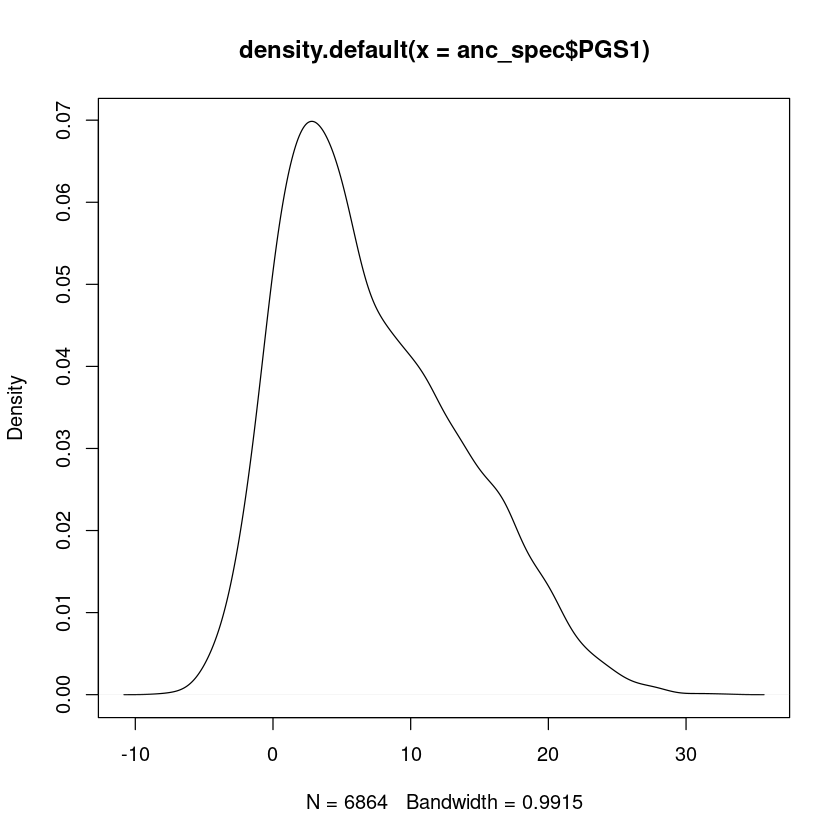

In [18]:
plot(density(anc_spec$PGS1))

make 2 dfs so i dont have to change score name in function

In [19]:
anc_split <- merge(anc_spec,total_df_pgsc[,c("subject_sp_id", "ASD", "age_at_registration_years", "SEX", "PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10", "ancestry") ], by = "subject_sp_id" )

pps_eur <- anc_split[c( "subject_sp_id", "PGS1", "PROP1", "pps1", "ASD", "age_at_registration_years", "SEX", "PC1", "PC2", "PC3", "PC4", "PC5", "ancestry")]
#colnames(pps_eur)[4] <- "SCORE"
colnames(pps_eur)[2] <- "SCORE"

pps_afr <- anc_split[c( "subject_sp_id", "PGS2", "PROP2", "pps2", "ASD", "age_at_registration_years", "SEX", "PC1", "PC2", "PC3", "PC4", "PC5", "ancestry")]    
#colnames(pps_afr)[4] <- "SCORE" 
colnames(pps_afr)[2] <- "SCORE"


#anc_split$sum_partial <- anc_split$pps1+anc_split$pps2 - these are z-scores
#rm(anc_split)

anc_split$sum_partial <- anc_split$PGS1+anc_split$PGS2

## linear model function

In [20]:
# function to get Nagelkerke r^2

nagel_value <- function(total_df){



############################### total set glm's

t_all <- glm(ASD~SCORE, family="binomial", data = total_df)
t_all_N <- PseudoR2(t_all, c("Nagelkerke"))

t_a_all <- glm(ASD~SCORE+age_at_registration_years, family="binomial", data = total_df)
t_a_all_N <- PseudoR2(t_a_all, c("Nagelkerke"))

t_s_all <- glm(ASD~SCORE+SEX, family="binomial", data = total_df)
t_s_all_N <- PseudoR2(t_s_all, c("Nagelkerke"))

t_as_all <- glm(ASD~SCORE+age_at_registration_years+SEX, family="binomial", data = total_df)
t_as_all_N <- PseudoR2(t_as_all, c("Nagelkerke"))

t_as3_all <- glm(ASD~SCORE+age_at_registration_years+SEX+PC1+PC2+PC3, family="binomial", data = total_df)
t_as3_all_N <- PseudoR2(t_as3_all, c("Nagelkerke"))

t_as4_all <- glm(ASD~SCORE+age_at_registration_years+SEX+PC1+PC2+PC3+PC4, family="binomial", data = total_df)
t_as4_all_N <- PseudoR2(t_as4_all, c("Nagelkerke"))

t_as5_all <- glm(ASD~SCORE+age_at_registration_years+SEX+PC1+PC2+PC3+PC4+PC5, family="binomial", data = total_df)
t_as5_all_N <- PseudoR2(t_as5_all, c("Nagelkerke"))

############################### european set glm's

w_all <- glm(ASD~SCORE, family="binomial", data = total_df[total_df$ancestry == "EUR",])
w_all_N <- PseudoR2(w_all, c("Nagelkerke"))

w_a_all <- glm(ASD~SCORE+age_at_registration_years, family="binomial", data = total_df[total_df$ancestry == "EUR",])
w_a_all_N <- PseudoR2(w_a_all, c("Nagelkerke"))

w_s_all <- glm(ASD~SCORE+SEX, family="binomial", data = total_df[total_df$ancestry == "EUR",])
w_s_all_N <- PseudoR2(w_s_all, c("Nagelkerke"))

w_as_all <- glm(ASD~SCORE+age_at_registration_years+SEX, family="binomial", data = total_df[total_df$ancestry == "EUR",])
w_as_all_N <- PseudoR2(w_as_all, c("Nagelkerke"))

w_as3_all <- glm(ASD~SCORE+age_at_registration_years+SEX+PC1+PC2+PC3, family="binomial", data = total_df[total_df$ancestry == "EUR",])
w_as3_all_N <- PseudoR2(w_as3_all, c("Nagelkerke"))

w_as4_all <- glm(ASD~SCORE+age_at_registration_years+SEX+PC1+PC2+PC3+PC4, family="binomial", data = total_df[total_df$ancestry == "EUR",])
w_as4_all_N <- PseudoR2(w_as4_all, c("Nagelkerke"))

w_as5_all <- glm(ASD~SCORE+age_at_registration_years+SEX+PC1+PC2+PC3+PC4+PC5, family="binomial", data = total_df[total_df$ancestry == "EUR",])
w_as5_all_N <- PseudoR2(w_as5_all, c("Nagelkerke"))

############################### AA set glm's

aa_all <- glm(ASD~SCORE, family="binomial", data = total_df[total_df$ancestry == "AFR",])
aa_all_N <- PseudoR2(aa_all, c("Nagelkerke"))

aa_a_all <- glm(ASD~SCORE+age_at_registration_years, family="binomial", data = total_df[total_df$ancestry == "AFR",])
aa_a_all_N <- PseudoR2(aa_a_all, c("Nagelkerke"))

aa_s_all <- glm(ASD~SCORE+SEX, family="binomial", data = total_df[total_df$ancestry == "AFR",])
aa_s_all_N <- PseudoR2(aa_s_all, c("Nagelkerke"))

aa_as_all <- glm(ASD~SCORE+age_at_registration_years+SEX, family="binomial", data = total_df[total_df$ancestry == "AFR",])
aa_as_all_N <- PseudoR2(aa_as_all, c("Nagelkerke"))

aa_as3_all <- glm(ASD~SCORE+age_at_registration_years+SEX+PC1+PC2+PC3, family="binomial", data = total_df[total_df$ancestry == "AFR",])
aa_as3_all_N <- PseudoR2(aa_as3_all, c("Nagelkerke"))

aa_as4_all <- glm(ASD~SCORE+age_at_registration_years+SEX+PC1+PC2+PC3+PC4, family="binomial", data = total_df[total_df$ancestry == "AFR",])
aa_as4_all_N <- PseudoR2(aa_as4_all, c("Nagelkerke"))

aa_as5_all <- glm(ASD~SCORE+age_at_registration_years+SEX+PC1+PC2+PC3+PC4+PC5, family="binomial", data = total_df[total_df$ancestry == "AFR",])
aa_as5_all_N <- PseudoR2(aa_as5_all, c("Nagelkerke"))


############################### make table of results

results_df <- cbind(
  c("Score", "Score, Age", "Score, Sex", "Score, Age, Sex", "Score, Age, Sex, PC1-3", "Score, Age, Sex, PC1-4", "Score, Age, Sex, PC1-5"), 
                   c(t_all_N, t_a_all_N, t_s_all_N, t_as_all_N, t_as3_all_N, t_as4_all_N, t_as5_all_N),
                   c(w_all_N, w_a_all_N, w_s_all_N, w_as_all_N, w_as3_all_N, w_as4_all_N, w_as5_all_N),
                   c(aa_all_N, aa_a_all_N, aa_s_all_N, aa_as_all_N, aa_as3_all_N, aa_as4_all_N, aa_as5_all_N))

colnames(results_df) <- c("Model", "Total Ancestry", "European Ancestry", "African American Ancestry")

rownames(results_df) <- NULL

return(results_df)
}

## replicate linear models - use nagel function

In [23]:
# sib subsets

sib_df_pgsc <- total_df_pgsc[total_df_pgsc$subject_sp_id %in% fs_score_spark$IID,]
#dim(total_df[(total_df$subject_sp_id %in% fs_score_spark$IID) & (total_df$race_white ==1),])

sib_df_j <- total_df_j[total_df_j$subject_sp_id %in% fs_score_spark$IID,]


ERROR: Error in total_df_pgsc$subject_sp_id %in% fs_score_spark$IID: object 'fs_score_spark' not found


In [24]:
fs_score_spark

ERROR: Error in eval(expr, envir, enclos): object 'fs_score_spark' not found
